In [17]:
import pandas as pd

test  = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned_lu.csv")
df = pd.read_csv(r"C:\Users\lclai\Desktop\transcripts_cleaned.csv")

### TRAIN

In [18]:
import pandas as pd
df['label'] = df['label'].replace({
    'ProbableAD': 'Dementia',
    'PossibleAD': 'Dementia',
    'MCI': 'Dementia'
    
})
df = df[~df['label'].isin(['Vascular', 'Memory', 'Other'])]
print(df['label'].value_counts())

label
Dementia    297
Control     243
Name: count, dtype: int64


In [19]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

def remove_inv_phrases(text):
    if isinstance(text, str):
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        cleaned = [s for s in sentences if not s.startswith("INV")]
        return '. '.join(cleaned) + ('.' if cleaned else '')

df["clean_transcripts"] = df["clean_transcripts"].apply(remove_inv_phrases)

sex = df["sex"].map({"male": 0, "female": 1}).to_numpy().reshape(-1, 1)
age = df["age"].to_numpy().reshape(-1, 1)
texts = df["clean_transcripts"].to_numpy()

y = LabelEncoder().fit_transform(df["label"])

X_raw = np.hstack((sex, age.reshape(-1, 1)))  

X_raw_train, X_raw_test, texts_train, texts_test, y_train, y_test = train_test_split(
    X_raw, texts, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(max_features=300)
X_text_train = vectorizer.fit_transform(texts_train).toarray()
X_text_test = vectorizer.transform(texts_test).toarray()

X_train = np.hstack((X_raw_train, X_text_train))
X_test = np.hstack((X_raw_test, X_text_test))

X_train = pd.DataFrame(X_train, columns=['sex','age']+ [f"feature_{i}" for i in range(X_train.shape[1] - 2)])
X_test = pd.DataFrame(X_test, columns=['sex','age']+ [f"feature_{i}" for i in range(X_test.shape[1] - 2)])
X_test

,sex,age,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_290,feature_291,feature_292,feature_293,feature_294,feature_295,feature_296,feature_297,feature_298,feature_299
0,0.0,72.0,0.075116,0.202995,0.000000,0.0,0.0,0.127179,0.0,0.000000,...,0.000000,0.082840,0.0,0.0,0.000000,0.0,0.0,0.144337,0.0,0.0
1,1.0,62.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.077964,0.0,0.0,0.092090,0.0,0.0,0.000000,0.0,0.0
2,1.0,65.0,0.000000,0.000000,0.068020,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.201284,0.0,0.0,0.148455,0.0,0.0
3,0.0,6100.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.122938,0.000000,0.0,0.0,0.000000,0.0,0.0,0.080513,0.0,0.0
4,0.0,7900.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.098074,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,1.0,69.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
105,0.0,6500.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
106,0.0,65.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
107,1.0,57.0,0.000000,0.000000,0.098655,0.0,0.0,0.000000,0.0,0.000000,...,0.000000,0.123578,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


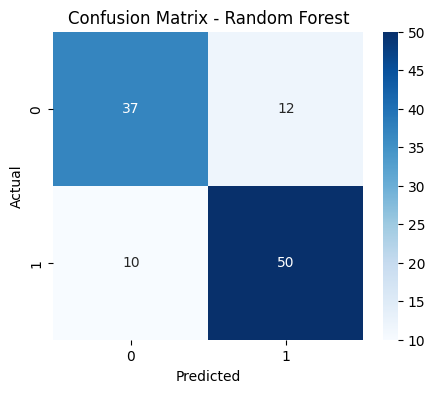

c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


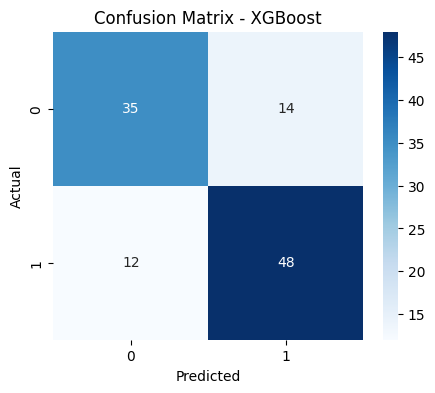

Model: Random Forest
Best Params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Mean AUC (CV=5): nan
STD AUC (CV=5): nan
AUC on Test Set: 0.8690

Model: XGBoost
Best Params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.8}
Mean AUC (CV=5): nan
STD AUC (CV=5): nan
AUC on Test Set: 0.8680



In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


non_scaled_columns = ['sex']  # no escalar
scaled_columns = [col for col in X_train.columns if col not in non_scaled_columns]


preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), scaled_columns)
    ],
    remainder='passthrough'  
)


models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}


param_grids = {
    'Random Forest': {
        'model__n_estimators': [500, 1000],
        'model__max_depth': [None, 2,10],
        'model__min_samples_split': [2,5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'model__n_estimators': [500, 1000],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 6, 10],
        'model__subsample': [0.8, 1.0]
    }
}

results = {}

for model_name in models:
    model = models[model_name]
    param_grid = param_grids[model_name]

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    mean_auc_cv = grid_search.best_score_
    std_auc_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_pred_proba)

    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results[model_name] = {
        'best_params': grid_search.best_params_,
        'mean_auc_cv': mean_auc_cv,
        'std_cv': std_auc_cv,
        'auc_test': auc_test,
        'best_model': best_model
    }

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

for model_name, result in results.items():
    print(f"Model: {model_name}")
    print(f"Best Params: {result['best_params']}")
    print(f"Mean AUC (CV=5): {result['mean_auc_cv']:.4f}")
    print(f"STD AUC (CV=5): {result['std_cv']:.4f}")
    print(f"AUC on Test Set: {result['auc_test']:.4f}\n")


## TEST

In [32]:
lu = test.copy()

In [33]:
lu['label'].value_counts()

label
Control        26
Alzheimer's    16
Dementia        6
MCI             2
Conrol          1
Pick's          1
Vascular        1
Aphasia         1
Name: count, dtype: int64

In [ ]:
import pandas as pd


lu['label'] = lu['label'].replace({'Conrol': 'Control'})
lu_binary = lu[lu['label'].isin(['Control', "Alzheimer's"])].copy()
lu_binary['label'] = lu_binary['label'].map({'Control': 0, "Alzheimer's": 1})
print(lu_binary['label'].value_counts())


label
0    27
1    16
Name: count, dtype: int64


In [48]:
lu = lu_binary.copy()
lu = lu.dropna()

In [49]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

sex = lu["sex"].map({"male": 0, "female": 1}).to_numpy().reshape(-1, 1)
age = lu["age"].to_numpy().reshape(-1, 1)
texts = lu["clean_transcripts"].to_numpy()

# Numerical features
lu_raw = np.hstack((sex, age))

# TF-IDF text features
vectorizer = TfidfVectorizer(max_features=300)
lu_texts = vectorizer.fit_transform(texts).toarray()

# Concatenate numeric + text features
lu_test = np.hstack((lu_raw, lu_texts))

# Build column names
column_names = ["sex", "age"] + [f"feature_{i}" for i in range(lu_texts.shape[1])]

# Convert to DataFrame
lu_test = pd.DataFrame(lu_test, columns=column_names)

lu_test = lu_test.dropna()
lu_test.head(5)


,sex,age,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_290,feature_291,feature_292,feature_293,feature_294,feature_295,feature_296,feature_297,feature_298,feature_299
0,0.0,95.0,0.000000,0.0,0.0,0.059161,0.000000,0.0,0.128432,0.0,...,0.139242,0.000000,0.0,0.0,0.124265,0.0,0.000000,0.000000,0.0,0.0
1,0.0,74.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.000000,0.0,0.0,0.470425,0.0,0.136775,0.214039,0.0,0.0
2,0.0,75.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.155461,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.234286,0.000000,0.0,0.0
3,1.0,67.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,...,0.000000,0.095065,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0
4,1.0,69.0,0.124715,0.0,0.0,0.000000,0.070899,0.0,0.097665,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0


c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\lclai\miniconda3\envs\envlaia\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.6585365853658537
Confusion Matrix:
 [[26  0]
 [14  1]]


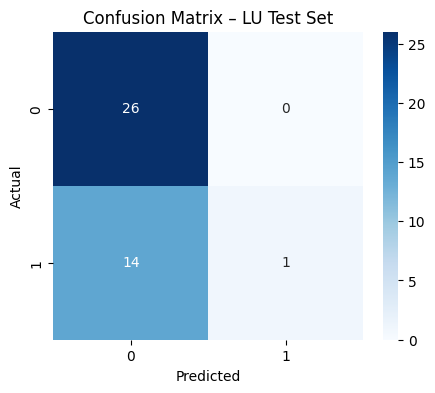

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_overall = max(results.items(), key=lambda x: x[1]["auc_test"])
best_model = best_overall[1]["best_model"]

clf = best_model.named_steps["model"]

y_pred = clf.predict(lu_test)
y_pred_proba = clf.predict_proba(lu_test)[:, 1]

y_lu = lu[['label']]

accuracy = accuracy_score(y_lu, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_lu, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – LU Test Set")
plt.show()
